# 04 — Render Diagram (matplotlib baseline)

> **Run-time:** ~5 seconds on CPU.
> **Prerequisites:** `uv sync --extra formal --extra dev`. FormalGeo7K
> v2 unpacked under `data/formalgeo7k_v2/`.

This notebook demos the matplotlib *baseline* renderer — the controlled
"obviously plotted" arm of the Phase 9 ablation against the GMBL-style
high-fidelity renderer (notebook 05).

The pipeline is intentionally minimal: regular n-gon layout (no constraint
solving), 0.8-px black strokes on white, serif vertex labels with small
jitter, ±5° rotation augmentation per call. Speed: ~30 ms / image at
224 px.

Long-form: [wiki/04-Diagram-Rendering.md](../wiki/04-Diagram-Rendering.md).


## 1. Load PID=1 and render it

`matplotlib_renderer.render(construction_cdl, image_cdl, *, shorter_edge_px, seed)`
returns a `PIL.Image`. The renderer's parser pulls point names out of
`Triangle(...)` / `Polygon(...)` / `Shape(...)` predicates, places each
point on a regular n-gon, then draws edges and labels.

PID=1 is the congruent-triangles problem from notebook 01 — two
`Shape(...)` predicates, so we should see two triangles.


image size = (224, 224), mode = RGB


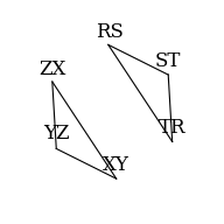

In [1]:
from open_geofm.formal.loader import load_problem
from open_geofm.render import matplotlib_renderer

p = load_problem(1)
img = matplotlib_renderer.render(
    p.construction_cdl, p.image_cdl, shorter_edge_px=224, seed=0,
)
print(f"image size = {img.size}, mode = {img.mode}")
img


The labels you see should correspond to the points named in the CDL:
`R, S, T` for the first triangle, `X, Y, Z` for the second. The baseline
does NOT enforce the *congruence* relation visually (that would require the
GMBL-style numerical-optimization layout in notebook 05) — both triangles
are drawn as approximately-equal regular shapes via the same layout
function. Numeric labels from `image_cdl` are drawn near the relevant
edges.

## 2. The three documented resolutions

The blueprint pins shorter-edge sizes at `{112, 224, 336}` to match
Qwen2-VL's `min_pixels / max_pixels` envelope (28 × patch_size 14 × merge
2). The Phase 7 training config sets `max_pixels = 1280 * 28 * 28`, which
allows up to a 336-px shorter edge — anything larger is wasted disk and
training time.


112: (112, 112), 224: (224, 224), 336: (336, 336)


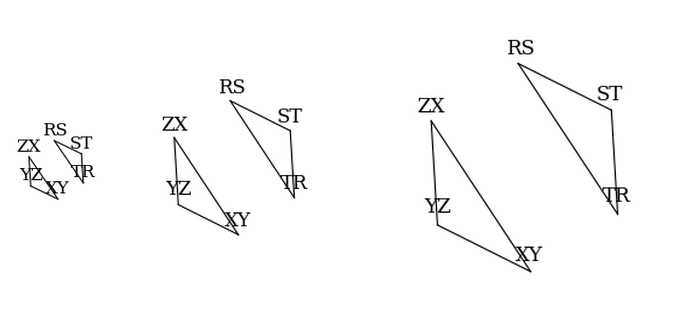

In [2]:
from PIL import Image as PILImage

renders = {
    edge: matplotlib_renderer.render(
        p.construction_cdl, p.image_cdl, shorter_edge_px=edge, seed=0,
    )
    for edge in (112, 224, 336)
}
# Stitch horizontally for a quick visual diff.
total_w = sum(r.width for r in renders.values()) + 20
strip = PILImage.new("RGB", (total_w, 336), color="white")
x = 0
for edge, r in renders.items():
    strip.paste(r, (x, (336 - r.height) // 2))
    x += r.width + 10
print(", ".join(f"{e}: {r.size}" for e, r in renders.items()))
strip


## 3. Rotation augmentation

The renderer applies a random ±5° rotation per call (paper §3.1). This
simulates the scan-skew of real textbook diagrams without bleeding into
distribution. Different `seed=` values produce different rotations.


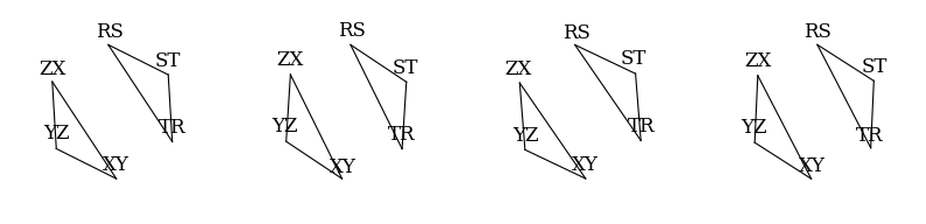

In [3]:
rotations = [
    matplotlib_renderer.render(
        p.construction_cdl, p.image_cdl, shorter_edge_px=224, seed=s,
    )
    for s in range(4)
]
strip = PILImage.new("RGB", (224 * 4 + 30, 224), color="white")
for i, r in enumerate(rotations):
    strip.paste(r, (i * (224 + 10), 0))
strip


## 4. Side-by-side with the dataset's real diagram

`data/formalgeo7k_v2/diagrams/<pid>.png` holds the original textbook
diagram for each PID. The fidelity gap between our matplotlib baseline
and the real diagram is the *motivation* for the GMBL-style renderer
(notebook 05) and the Phase 9 ablation that quantifies how much renderer
quality matters for eval accuracy.


LEFT: dataset diagram          RIGHT: matplotlib baseline (ours)


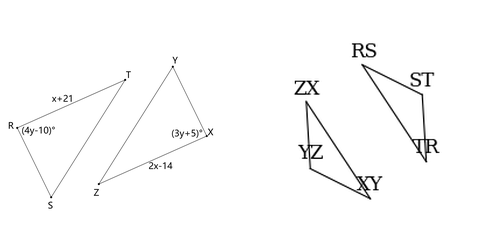

In [4]:
from pathlib import Path

real_path = Path("data/formalgeo7k_v2/diagrams/1.png")
if real_path.exists():
    real = PILImage.open(real_path).convert("RGB")
    real_resized = real.resize((224, 224), PILImage.LANCZOS)
    ours = matplotlib_renderer.render(
        p.construction_cdl, p.image_cdl, shorter_edge_px=224, seed=0,
    )
    side = PILImage.new("RGB", (224 * 2 + 30, 224 + 20), color="white")
    side.paste(real_resized, (0, 20))
    side.paste(ours, (224 + 30, 20))
    print("LEFT: dataset diagram          RIGHT: matplotlib baseline (ours)")
    display(side)  # noqa: F821 — Jupyter builtin
else:
    print(f"{real_path} not found — run scripts/01_download_formalgeo7k.sh.")


## 5. What's *not* in the baseline

* **No constraint solving.** A right triangle 3-4-5 will draw as an
  equilateral triangle — the *labels* still say 3 and 4, but the shape
  doesn't reflect them. Notebook 05's GMBL-style renderer fixes this with
  `scipy.optimize.minimize` over an L2 residual.
* **No auxiliary lines.** Cevians, perpendicular bisectors, altitudes
  aren't drawn (affects ~10–15% of FormalGeo7K).
* **No tick / arc marks for equal segments / angles.** Substituted with
  text labels.

These are intentional simplifications to keep the baseline a controlled
comparison point. The Phase 9 ablation result (matplotlib vs GMBL) is the
*motivation* — expect a +3–5 pp gap on MathVista-GPS in favour of GMBL.

## What's next

* **Notebook 05 — Render Diagram (GMBL-style):** the same input through
  the L-BFGS-based numerical-optimization renderer.
* **Wiki page 04 — Diagram Rendering:** the long-form companion.
